# Notebook 04 — Merge, Feature Engineering & Crisis Score
## Early Warning System Krisis Pariwisata Bali

Notebook ini digunakan untuk:
1. Load semua data hasil pemrosesan dari notebook sebelumnya
2. Sinkronisasi timeline ke jadi bulanan
3. Merge semua dataset menjadi satu dataset final
4. Feature engineering (growth rate, volatility, anomaly score, dll)
5. Menghitung Crisis Score menggunakan metode pembobotan
6. Buat label tingkat krisis (low / medium / high)
7. Visualisasi final dan menyimpan dataset final

**Output:** `data/final/crisis_dataset_final.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../data/final', exist_ok=True)

print('✓Library siap')

✓Library siap


## 1. Load Semua Data Processed

In [2]:
# Load wisman gabungan
wisman = pd.read_csv('../data/processed/wisman_clean.csv')
wisman['month'] = pd.PeriodIndex(wisman['month'], freq='M')
print(f'wisman: {wisman.shape}, dari {wisman["month"].min()} hingga {wisman["month"].max()}')

# Load wisnus
wisnus = pd.read_csv('../data/processed/wisnus_clean.csv')
wisnus['month'] = pd.PeriodIndex(wisnus['month'], freq='M')
print(f'wisnus: {wisnus.shape}, dari {wisnus["month"].min()} hingga {wisnus["month"].max()}')

# Load kurs USD/IDR
monthly_usd = pd.read_csv('../data/processed/monthly_usd.csv')
monthly_usd['month'] = pd.PeriodIndex(monthly_usd['month'], freq='M')
print(f'monthly_usd: {monthly_usd.shape}')

# Load forex
# monthly_forex = pd.read_csv('../data/processed/monthly_forex.csv')
# monthly_forex['month'] = pd.PeriodIndex(monthly_forex['month'], freq='M')
# print(f'monthly_forex: {monthly_forex.shape}')

# Load TPK
tpk = pd.read_csv('../data/processed/tpk_clean.csv')
tpk['month'] = pd.PeriodIndex(tpk['month'], freq='M')
print(f'tpk: {tpk.shape}')

# Load inflasi
inflasi = pd.read_csv('../data/processed/inflasi_clean.csv')
inflasi['month'] = pd.PeriodIndex(inflasi['month'], freq='M')
print(f'inflasi: {inflasi.shape}')

# Load monthly_sentiment + sentiment_stats (fallback)
monthly_sentiment = pd.read_csv('../data/processed/monthly_sentiment.csv')
monthly_sentiment['month'] = pd.PeriodIndex(monthly_sentiment['month'], freq='M')
print(f'monthly_sentiment: {monthly_sentiment.shape}, {monthly_sentiment["month"].min()} -> {monthly_sentiment["month"].max()}')

sentiment_stats = pd.read_csv('../data/processed/sentiment_stats.csv')
print(f'sentiment_stats (fallback): {sentiment_stats.shape}')
print()
print('Semua data berhasil dimuat!')

# Load wisman Bali vs Indonesia tahunan
wisman_indo = pd.read_csv('../data/processed/wisman_vs_indonesia_clean.csv')
print(f'wisman_indo: {wisman_indo.shape}, tahun {wisman_indo["tahun"].min()}-{wisman_indo["tahun"].max()}')

# Load External Risk Score (hasil notebook 04_2 — HARUS dijalankan lebih dulu)
external_risk = pd.read_csv('../data/processed/combined_additional_features_engineered_new.csv')
external_risk['date'] = pd.to_datetime(external_risk['date'])
external_risk['month'] = external_risk['date'].dt.to_period('M')
print(f'external_risk: {external_risk.shape}, dari {external_risk["month"].min()} hingga {external_risk["month"].max()}')


wisman: (192, 3), dari 2009-01 hingga 2024-12
wisnus: (264, 3), dari 2004-01 hingga 2025-12
monthly_usd: (180, 2)
tpk: (315, 4)
inflasi: (204, 3)
monthly_sentiment: (169, 8), 2009-05 -> 2026-05
sentiment_stats (fallback): (1, 5)

Semua data berhasil dimuat!
wisman_indo: (57, 4), tahun 1969-2025
external_risk: (204, 17), dari 2009-01 hingga 2025-12


## 2. Sinkronisasi Timeline & Merge Semua Dataset

In [3]:
final_df = wisman[['month', 'wisman']].copy()
print(f'Backbone timeline: {len(final_df)} baris')

# Merge wisnus
final_df = final_df.merge(
    wisnus[['date', 'month', 'wisnus']],
    on='month', how='left'
)

# Merge kurs USD/IDR
final_df = final_df.merge(
    monthly_usd[['month', 'usd_idr_avg']],
    on='month', how='left'
)

# # Merge forex IDR/EUR
# final_df = final_df.merge(
#     monthly_forex[['month', 'idr_eur_rate']],
#     on='month', how='left'
# )

# Merge TPK
final_df = final_df.merge(
    tpk[['date', 'month', 'tpk_bintang', 'tpk_non_bintang']],
    on='month', how='left'
)

# Merge inflasi
final_df = final_df.merge(
    inflasi[['date', 'month', 'inflasi_processed']],
    on='month', how='left'
)

# Merge wisman Bali vs Indonesia (data tahunan — join by tahun)
final_df['tahun'] = final_df['month'].dt.year
final_df = final_df.merge(
    wisman_indo[['tahun', 'indonesia_total', 'bali_share_pct']],
    on='tahun', how='left'
)
final_df.drop(columns=['tahun'], inplace=True)

# Merge monthly_sentiment berdasarkan bulan (bervariasi per bulan!)
final_df = final_df.merge(
    monthly_sentiment[['month', 'avg_sentiment', 'pct_negative', 'pct_positive', 'pct_neutral', 'review_count', 'avg_rating']],
    on='month', how='left'
)

# Mengisi bulan tanpa data ulasan dengan nilai global
global_avg_sentiment = sentiment_stats['avg_sentiment'].values[0]
global_pct_negative  = sentiment_stats['pct_negative'].values[0]
global_pct_positive = sentiment_stats['pct_positive'].values[0]
global_pct_neutral = sentiment_stats['pct_neutral'].values[0]
final_df['avg_sentiment'].fillna(global_avg_sentiment, inplace=True)
final_df['pct_negative'].fillna(global_pct_negative, inplace=True)
final_df['pct_positive'].fillna(global_pct_positive, inplace=True)
final_df['pct_neutral'].fillna(global_pct_neutral, inplace=True)

# Rename agar konsisten dengan kode downstream
final_df.rename(columns={
    'avg_sentiment': 'avg_sentiment_monthly',
    'pct_negative':  'pct_negative_monthly',
    'pct_positive': 'pct_positive_monthly',
    'pct_neutral': 'pct_neutral_monthly',
}, inplace=True)

print('Monthly sentiment coverage:')
print(f'  Bulan dengan data review nyata: {final_df["review_count"].notna().sum()}/192')
print(f'  Bulan fallback (tanpa review): {final_df["review_count"].isna().sum()}/192')

# Merge External Risk Score
final_df = final_df.merge(
    external_risk[['month', 'external_risk_avg', 'external_risk_max', 'external_risk_range']],
    on='month', how='left'
)

print(f'Shape setelah merge: {final_df.shape}')
print()
print('Missing values per kolom:')
print(final_df.isnull().sum().to_string())
print()
final_df.head(5)

Backbone timeline: 192 baris
Monthly sentiment coverage:
  Bulan dengan data review nyata: 152/192
  Bulan fallback (tanpa review): 40/192
Shape setelah merge: (192, 21)

Missing values per kolom:
month                     0
wisman                    0
date_x                    0
wisnus                    0
usd_idr_avg              12
date_y                    0
tpk_bintang               0
tpk_non_bintang          60
date                      0
inflasi_processed         0
indonesia_total           0
bali_share_pct            0
avg_sentiment_monthly     0
pct_negative_monthly      0
pct_positive_monthly      0
pct_neutral_monthly       0
review_count             40
avg_rating               58
external_risk_avg         0
external_risk_max         0
external_risk_range       0



,month,wisman,date_x,wisnus,usd_idr_avg,date_y,tpk_bintang,tpk_non_bintang,date,inflasi_processed,...,bali_share_pct,avg_sentiment_monthly,pct_negative_monthly,pct_positive_monthly,pct_neutral_monthly,review_count,avg_rating,external_risk_avg,external_risk_max,external_risk_range
0,2009-01,174541,2009-01-01,264915.0,NaN,2009-01-01,47.254,29.32,2009-01-01,9.17,...,37.72,0.310578,25.107009,68.16601,6.726981,NaN,NaN,0.367944,0.786474,0.711077
1,2009-02,147704,2009-02-01,204419.0,NaN,2009-02-01,44.210,24.35,2009-02-01,8.60,...,37.72,0.310578,25.107009,68.16601,6.726981,NaN,NaN,0.362267,0.738609,0.645907
2,2009-03,168205,2009-03-01,255203.0,NaN,2009-03-01,48.350,32.27,2009-03-01,7.92,...,37.72,0.310578,25.107009,68.16601,6.726981,NaN,NaN,0.395440,0.702182,0.665142
3,2009-04,188776,2009-04-01,247100.0,NaN,2009-04-01,53.426,33.41,2009-04-01,7.31,...,37.72,0.310578,25.107009,68.16601,6.726981,NaN,NaN,0.360803,0.701312,0.674988
4,2009-05,190803,2009-05-01,289635.0,NaN,2009-05-01,55.382,33.74,2009-05-01,6.04,...,37.72,-0.668431,100.000000,0.00000,0.000000,1.0,NaN,0.311416,0.651955,0.618255


In [4]:
# Handle missing values
# Forward fill untuk kurs dan TPK (jika ada gap)
# cols_to_ffill = ['usd_idr_avg', 'idr_eur_rate', 'tpk_avg', 'inflasi_bali', 'bali_share_pct', 'indonesia_total']
cols_to_ffill = ['usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 
                 'inflasi_processed', 'bali_share_pct', 'indonesia_total',
                 'external_risk_avg', 'external_risk_max', 'external_risk_range']
for col in cols_to_ffill:
    if col in final_df.columns:
        before = final_df[col].isnull().sum()
        final_df[col] = final_df[col].ffill().bfill()
        after = final_df[col].isnull().sum()
        print(f'  {col}: {before} -> {after} missing')

# Mengisi data wisnus dengan interpolasi
if 'wisnus' in final_df.columns:
    final_df['wisnus'] = final_df['wisnus'].interpolate(method='linear')

print('\nMissing values setelah handle:')
print(final_df.isnull().sum().to_string())

  usd_idr_avg: 12 -> 0 missing
  tpk_bintang: 0 -> 0 missing
  tpk_non_bintang: 60 -> 0 missing
  inflasi_processed: 0 -> 0 missing
  bali_share_pct: 0 -> 0 missing
  indonesia_total: 0 -> 0 missing
  external_risk_avg: 0 -> 0 missing
  external_risk_max: 0 -> 0 missing
  external_risk_range: 0 -> 0 missing

Missing values setelah handle:
month                     0
wisman                    0
date_x                    0
wisnus                    0
usd_idr_avg               0
date_y                    0
tpk_bintang               0
tpk_non_bintang           0
date                      0
inflasi_processed         0
indonesia_total           0
bali_share_pct            0
avg_sentiment_monthly     0
pct_negative_monthly      0
pct_positive_monthly      0
pct_neutral_monthly       0
review_count             40
avg_rating               58
external_risk_avg         0
external_risk_max         0
external_risk_range       0


## 3. Feature Engineering

In [5]:
# ============================================================
# FEATURE ENGINEERING — Buat fitur-fitur untuk model early warning
# ============================================================

# Inisialisasi new_features di awal agar bisa diappend di setiap langkah
new_features = []

# 1. Growth rate wisatawan (persentase perubahan month-over-month)
final_df['wisman_growth_mom'] = final_df['wisman'].pct_change()
final_df['wisnus_growth_mom'] = final_df['wisnus'].pct_change() if 'wisnus' in final_df.columns else 0
new_features += ['wisman_growth_mom', 'wisnus_growth_mom']

# 2. Growth rate wisatawan Year-over-Year (12 bulan)
final_df['wisman_growth_yoy'] = final_df['wisman'].pct_change(periods=12)
new_features.append('wisman_growth_yoy')

# 3. Rolling average 3 bulan dan 6 bulan
final_df['wisman_ma3'] = final_df['wisman'].rolling(3).mean()
final_df['wisman_ma6'] = final_df['wisman'].rolling(6).mean()
new_features += ['wisman_ma3', 'wisman_ma6']

# 4. Volatilitas kurs USD (rolling std 3 bulan)
if 'usd_idr_avg' in final_df.columns:
    final_df['usd_volatility_3m'] = final_df['usd_idr_avg'].rolling(3).std()
    final_df['usd_change_mom'] = final_df['usd_idr_avg'].pct_change()
    new_features += ['usd_volatility_3m', 'usd_change_mom']

# 5. Z-score anomali kunjungan wisatawan
rolling_mean_12m = final_df['wisman'].rolling(12).mean()
rolling_std_12m  = final_df['wisman'].rolling(12).std()
final_df['wisman_zscore'] = (final_df['wisman'] - rolling_mean_12m) / rolling_std_12m
new_features.append('wisman_zscore')

# 6. Flag anomali (z-score < -2 = anomali penurunan)
final_df['is_anomaly'] = (final_df['wisman_zscore'] < -2).astype(int)
new_features.append('is_anomaly')

# 7. Sesonalitas — bulan sebagai fitur
final_df['month_num'] = final_df['month'].dt.month
final_df['is_peak_season'] = final_df['month_num'].isin([7, 8, 12]).astype(int)  # Juli, Agustus, Desember
new_features += ['month_num', 'is_peak_season']

# 8. Label periode krisis COVID (untuk training/validasi)
final_df['month_dt'] = final_df['month'].dt.to_timestamp()
final_df['is_covid_period'] = (
    (final_df['month_dt'] >= '2020-03-01') &
    (final_df['month_dt'] <= '2021-12-31')
).astype(int)
new_features.append('is_covid_period')

# 9. Bali share dari wisman Indonesia sebagai indikator daya saing regional
# Dipindahkan SETELAH new_features didefinisikan agar tidak NameError
if 'bali_share_pct' in final_df.columns:
    final_df['bali_share_change'] = final_df['bali_share_pct'].diff()  
    new_features.append('bali_share_change')

# 10. TPK bintang sebagai indikator okupansi hotel
if 'tpk_bintang' in final_df.columns:
    final_df['tpk_change_mom'] = final_df['tpk_bintang'].diff()
    final_df['tpk_ma3'] = final_df['tpk_bintang'].rolling(3).mean()
    new_features += ['tpk_change_mom', 'tpk_ma3']

# 11. Pre-COVID baseline untuk floor rule
precovid_mean = final_df[
    final_df['month'].dt.year.between(2017, 2019)
]['wisman'].mean()
final_df['wisman_precovid_mean'] = precovid_mean
new_features.append('wisman_precovid_mean')

print('Feature engineering selesai!')
print('Fitur baru yang dibuat:')
for f in new_features:
    if f in final_df.columns:
        print(f'  {f}')


Feature engineering selesai!
Fitur baru yang dibuat:
  wisman_growth_mom
  wisnus_growth_mom
  wisman_growth_yoy
  wisman_ma3
  wisman_ma6
  usd_volatility_3m
  usd_change_mom
  wisman_zscore
  is_anomaly
  month_num
  is_peak_season
  is_covid_period
  bali_share_change
  tpk_change_mom
  tpk_ma3
  wisman_precovid_mean


## 3b. Feature Engineering Lanjutan — Lag & Rolling Trend

Ditambahkan untuk menangkap pola temporal yang tidak dapat direpresentasikan oleh nilai saat ini saja, meliputi::
- **Lag features** (`wisman_lag_1`, `wisman_lag_3`): untuk merepresentasikan dampak yang muncul beberapa periode setelah suatu kejadian atau krisis.
- **Rolling trend** (`wisman_trend_3m`): untuk mengidentifikasi arah perubahan data dalam beberapa bulan terakhir, baik meningkat maupun menurun.
- **Regime features**: untuk mengidentifikasi kondisi pasca-COVID dan tingkat pemulihan terhadap baseline 2017–2019.


In [6]:
# ============================================================
# FEATURE ENGINEERING LANJUTAN — Lag Features & Rolling Trend
# ============================================================

# ── 12. Lag Features — delayed effect ────────────────────────
# Krisis pariwisata sering punya efek tertunda contoh bulan ini turun = next month makin buruk
final_df['wisman_lag_1'] = final_df['wisman'].shift(1)
final_df['wisman_lag_3'] = final_df['wisman'].shift(3)

# Lag untuk TPK (hunian hotel biasanya delayed vs kunjungan)
if 'tpk_bintang' in final_df.columns:
    final_df['tpk_lag_1'] = final_df['tpk_bintang'].shift(1)

# Lag untuk sentimen (review biasanya diposting setelah menginap, bukan realtime)
if 'avg_sentiment_monthly' in final_df.columns:
    final_df['sentiment_lag_1'] = final_df['avg_sentiment_monthly'].shift(1)

# ── 13. Rolling Trend Direction ───────────────────────────────
# Slope dari rolling 3 bulan untuk mendeteksi arah tren (naik/turun)
import numpy as np

def rolling_slope(series, window=3):
    """Hitung slope (arah tren) dari rolling window menggunakan polyfit."""
    return series.rolling(window).apply(
        lambda x: float(np.polyfit(range(len(x)), x, 1)[0])
        if len(x) == window else np.nan,
        raw=True
    )

final_df['wisman_trend_3m']    = rolling_slope(final_df['wisman'], 3)
if 'avg_sentiment_monthly' in final_df.columns:
    final_df['sentiment_trend_3m'] = rolling_slope(final_df['avg_sentiment_monthly'], 3)
if 'usd_idr_avg' in final_df.columns:
    final_df['usd_trend_3m']       = rolling_slope(final_df['usd_idr_avg'], 3)

# ── 14. Regime Features ──────────────────────────────────────
if 'is_covid_period' not in final_df.columns:
    final_df['month_dt'] = final_df['month'].dt.to_timestamp()
    final_df['is_covid_period'] = (
        (final_df['month_dt'] >= '2020-03-01') &
        (final_df['month_dt'] <= '2021-12-31')
    ).astype(int)

# Post-COVID recovery period
final_df['is_postcovid'] = (
    (final_df['month'].dt.to_timestamp() >= '2022-01-01') &
    (final_df['month'].dt.to_timestamp() <= '2022-12-31')
).astype(int)

# Pre-pandemic peak reference
precovid = final_df[final_df['month'].dt.year.between(2017,2019)]['wisman'].mean()
final_df['wisman_recovery_pct'] = (final_df['wisman'] / precovid * 100).round(2)

# Print summary
lag_cols = ['wisman_lag_1','wisman_lag_3','tpk_lag_1','sentiment_lag_1',
            'wisman_trend_3m','sentiment_trend_3m','usd_trend_3m',
            'is_postcovid','wisman_recovery_pct']
print('=== Fitur Lag & Trend Baru ===')
for c in lag_cols:
    if c in final_df.columns:
        non_null = final_df[c].notna().sum()
        print(f'  {c:30s}: {non_null}/{len(final_df)} non-null')
    else:
        print(f'  {c:30s}: tidak dibuat (kolom sumber tidak ada)')


=== Fitur Lag & Trend Baru ===
  wisman_lag_1                  : 191/192 non-null
  wisman_lag_3                  : 189/192 non-null
  tpk_lag_1                     : 191/192 non-null
  sentiment_lag_1               : 191/192 non-null
  wisman_trend_3m               : 190/192 non-null
  sentiment_trend_3m            : 190/192 non-null
  usd_trend_3m                  : 190/192 non-null
  is_postcovid                  : 192/192 non-null
  wisman_recovery_pct           : 192/192 non-null


## 3c. Fungsi `build_features(df)` — Untuk Pipeline Otomatis

Seluruh feature engineering di-wrap menjadi satu fungsi.
`update_pipeline.py` mengimpor fungsi ini agar setiap update data bulanan
menghasilkan fitur yang **persis sama** dengan notebook.


In [7]:
# ============================================================
# Penerapan Fungsi build_features() pada File update_pipeline.py
# ============================================================
# Seluruh proses feature engineering dirangkum dalam satu fungsi agar konsisten digunakan baik pada notebook maupun pipeline otomatis.

import numpy as np
import pandas as pd

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bangun seluruh fitur BaliGuard dari dataframe mentah.

    Kolom INPUT minimal:
      month (Period/str), wisman, usd_idr_avg, tpk_bintang,
      avg_sentiment_monthly, bali_share_pct, inflasi_processed

    Kolom OUTPUT: semua kolom input + seluruh fitur engineered.
    Fungsi ini dipanggil oleh update_pipeline.py setiap bulan.
    """
    df = df.copy()

    # ── 1. Growth rates ──────────────────────────────────────
    df['wisman_growth_mom'] = df['wisman'].pct_change()
    df['wisman_growth_yoy'] = df['wisman'].pct_change(periods=12)
    if 'wisnus' in df.columns:
        df['wisnus_growth_mom'] = df['wisnus'].pct_change()

    # ── 2. Rolling averages ──────────────────────────────────
    df['wisman_ma3'] = df['wisman'].rolling(3).mean()
    df['wisman_ma6'] = df['wisman'].rolling(6).mean()

    # ── 3. Kurs USD/IDR ──────────────────────────────────────
    if 'usd_idr_avg' in df.columns:
        df['usd_volatility_3m'] = df['usd_idr_avg'].rolling(3).std()
        df['usd_change_mom']    = df['usd_idr_avg'].pct_change()

    # ── 4. Z-score anomali ───────────────────────────────────
    rm12  = df['wisman'].rolling(12).mean()
    rs12  = df['wisman'].rolling(12).std()
    df['wisman_zscore'] = (df['wisman'] - rm12) / rs12
    df['is_anomaly']    = (df['wisman_zscore'] < -2).astype(int)

    # ── 5. Sesonalitas & konteks ─────────────────────────────
    month_series = df['month']
    if hasattr(month_series.iloc[0], 'month'):
        df['month_num']      = month_series.apply(lambda x: x.month)
        df['is_peak_season'] = month_series.apply(lambda x: x.month in [7, 8, 12]).astype(int)
        year_series          = month_series.apply(lambda x: x.year)
    else:
        dt = pd.to_datetime(month_series.astype(str))
        df['month_num']      = dt.dt.month
        df['is_peak_season'] = dt.dt.month.isin([7, 8, 12]).astype(int)
        year_series          = dt.dt.year

    # ── 6. Regime ────────────────────────────────────────────
    dt_ts = pd.to_datetime(df['month'].astype(str))
    df['is_covid_period'] = (
        (dt_ts >= '2020-03-01') & (dt_ts <= '2021-12-31')
    ).astype(int)
    df['is_postcovid'] = (
        (dt_ts >= '2022-01-01') & (dt_ts <= '2022-12-31')
    ).astype(int)

    # ── 7. Bali share ────────────────────────────────────────
    if 'bali_share_pct' in df.columns:
        df['bali_share_change'] = df['bali_share_pct'].diff()

    # ── 8. TPK ───────────────────────────────────────────────
    if 'tpk_bintang' in df.columns:
        df['tpk_change_mom'] = df['tpk_bintang'].diff()
        df['tpk_ma3']        = df['tpk_bintang'].rolling(3).mean()

    # ── 9. Pre-COVID baseline ────────────────────────────────
    mask_precovid = year_series.between(2017, 2019)
    precovid_mean = df.loc[mask_precovid, 'wisman'].mean() if mask_precovid.sum() > 0 else df['wisman'].mean()
    df['wisman_precovid_mean'] = precovid_mean
    df['wisman_recovery_pct']  = (df['wisman'] / precovid_mean * 100).round(2)

    # ── 10. Lag features (delayed effect) ───────────────────
    df['wisman_lag_1']    = df['wisman'].shift(1)
    df['wisman_lag_3']    = df['wisman'].shift(3)
    if 'tpk_bintang' in df.columns:
        df['tpk_lag_1']   = df['tpk_bintang'].shift(1)
    if 'avg_sentiment_monthly' in df.columns:
        df['sentiment_lag_1'] = df['avg_sentiment_monthly'].shift(1)

    # ── 11. Rolling trend direction (slope) ──────────────────
    def rolling_slope(series, window=3):
        return series.rolling(window).apply(
            lambda x: float(np.polyfit(range(len(x)), x, 1)[0])
            if len(x) == window else np.nan, raw=True)

    df['wisman_trend_3m'] = rolling_slope(df['wisman'], 3)
    if 'avg_sentiment_monthly' in df.columns:
        df['sentiment_trend_3m'] = rolling_slope(df['avg_sentiment_monthly'], 3)
    if 'usd_idr_avg' in df.columns:
        df['usd_trend_3m'] = rolling_slope(df['usd_idr_avg'], 3)

    return df


# ── Verifikasi fungsi ─────────────────────────────────────────
print('build_features() terdefinisi dan siap diimpor')
print('   Lokasi: notebook ini (dan akan di-export ke feature_engineering.py)')
print()

# Uji dengan final_df yang sudah ada
test_df = build_features(final_df[['month','wisman','wisnus','usd_idr_avg',
    'tpk_bintang','avg_sentiment_monthly','bali_share_pct','inflasi_processed',
    'indonesia_total']].copy())

new_cols = ['wisman_lag_1','wisman_lag_3','wisman_trend_3m',
            'wisman_recovery_pct','is_postcovid','sentiment_lag_1']
print('Fitur baru dari build_features():')
for c in new_cols:
    status = '✓' if c in test_df.columns else '✗'
    print(f'  {status} {c}')


build_features() terdefinisi dan siap diimpor
   Lokasi: notebook ini (dan akan di-export ke feature_engineering.py)

Fitur baru dari build_features():
  ✓ wisman_lag_1
  ✓ wisman_lag_3
  ✓ wisman_trend_3m
  ✓ wisman_recovery_pct
  ✓ is_postcovid
  ✓ sentiment_lag_1


## 4. Normalisasi Fitur

In [8]:
# Normalisasi fitur numerik tiap komponen terpisah ke skala 0-1 untuk digunakan dalam Crisis Score

scaler = MinMaxScaler()

cols_to_normalize = [
    'wisman_growth_mom',
    'wisman_growth_yoy',
    'usd_volatility_3m',
    'usd_change_mom'
]

# Hanya normalize kolom yang ada
cols_to_normalize = [c for c in cols_to_normalize if c in final_df.columns]

# Buat salinan untuk normalisasi
temp_norm = final_df[cols_to_normalize].copy()

# Clip outlier ekstrem sebelum normalisasi
for col in cols_to_normalize:
    q1 = temp_norm[col].quantile(0.05)
    q99 = temp_norm[col].quantile(0.95)
    temp_norm[col] = temp_norm[col].clip(q1, q99)

# Normalisasi
final_df[[f'{c}_norm' for c in cols_to_normalize]] = scaler.fit_transform(
    temp_norm.fillna(0)
)

print('Normalisasi selesai!')
print('Kolom normalized:', [f'{c}_norm' for c in cols_to_normalize])

Normalisasi selesai!
Kolom normalized: ['wisman_growth_mom_norm', 'wisman_growth_yoy_norm', 'usd_volatility_3m_norm', 'usd_change_mom_norm']


## 5. Hitung Crisis Score

```
Crisis Score = (0.35 × S_sentimen) + (0.30 × S_kunjungan) + (0.20 × S_ekonomi) + (0.15 × S_cuaca)
```

Karena data cuaca tidak tersedia, bobot didistribusikan ulang:

In [9]:
# ============================================================
# CRISIS SCORE KOMPOSIT
# Bobot yang disesuaikan (tanpa data cuaca):
#   - Komponen kunjungan wisatawan : 45%
#   - Komponen ekonomi (kurs)      : 30%
#   - Komponen sentimen (global)   : 25%
# ============================================================

def compute_crisis_component_tourism(row):
    """
    Komponen krisis dari data kunjungan wisatawan.
    Semakin besar penurunan, semakin tinggi skor krisis.
    Output: 0-1 (1 = sangat krisis)
    """
    # Growth negatif=krisis
    growth_score = 0.0
    if 'wisman_growth_mom_norm' in row.index and not pd.isna(row['wisman_growth_mom_norm']):
        growth_score = 1 - row['wisman_growth_mom_norm']
    
    # Z-score anomali (Z-score sangat negatif = krisis)
    zscore_score = 0.0
    if not pd.isna(row.get('wisman_zscore', np.nan)):
        zscore_raw = min(max(-row['wisman_zscore'], 0), 4)
        zscore_score = zscore_raw / 4
    
    return (growth_score * 0.6) + (zscore_score * 0.4)

def compute_crisis_component_economy(row):
    econ_score = 0.0
    # USD volatility (50%)
    if 'usd_volatility_3m_norm' in row.index and not pd.isna(row['usd_volatility_3m_norm']):
        econ_score += row['usd_volatility_3m_norm'] * 0.4
    if 'usd_change_mom_norm' in row.index and not pd.isna(row['usd_change_mom_norm']):
        econ_score += row['usd_change_mom_norm'] * 0.3
    # Penurunan TPK sebagai indikator ekonomi
    if 'tpk_bintang' in row.index and not pd.isna(row.get('tpk_bintang')):
        # TPK rendah (<40%) sebagai indikator tekanan ekonomi, dinormalisasi terbalik
        tpk_score = max(0, (60 - row['tpk_bintang']) / 60)
        econ_score += tpk_score * 0.3
    return min(econ_score, 1.0)

def compute_crisis_component_sentiment(row):
    """
    DIPERBARUI: Komponen krisis dari sentimen bulanan (bukan lagi statis).
    Menggunakan avg_sentiment_monthly yang bervariasi per bulan.
    Output: 0-1 (1 = sentimen sangat negatif = krisis)
    """
    pct_neg  = row.get('pct_negative_monthly', 29.0)
    avg_sent = row.get('avg_sentiment_monthly', 0.22)

    # Persentase ulasan negatif (bobot 60%)
    neg_score = pct_neg / 100.0

    # Sentimen negatif memberikan skor krisis lebih tinggi melalui inversi nilai rata-rata sentimen
    # avg_sentiment: -1 (negatif) hingga +1 (positif)
    sent_score = max(0, (0 - avg_sent) / 2 + 0.5)

    return min((neg_score * 0.6) + (sent_score * 0.4), 1.0)

print('Fungsi crisis component siap!')

Fungsi crisis component siap!


In [10]:
# Hitung setiap komponen
final_df['crisis_component_tourism'] = final_df.apply(compute_crisis_component_tourism, axis=1)
final_df['crisis_component_economy'] = final_df.apply(compute_crisis_component_economy, axis=1)
final_df['crisis_component_sentiment'] = final_df.apply(compute_crisis_component_sentiment, axis=1)
final_df['external_risk_score'] = final_df['external_risk_avg']

# Hitung Crisis Score komposit berbobot
WEIGHT_TOURISM   = 0.45
WEIGHT_ECONOMY   = 0.25
WEIGHT_EXTERNAL  = 0.20
WEIGHT_SENTIMENT = 0.10

final_df['crisis_score'] = (
    WEIGHT_TOURISM   * final_df['crisis_component_tourism'] +
    WEIGHT_ECONOMY   * final_df['crisis_component_economy'] +
    WEIGHT_EXTERNAL  * final_df['external_risk_score'] +
    WEIGHT_SENTIMENT * final_df['crisis_component_sentiment']
)

final_df['crisis_score_100'] = final_df['crisis_score'] * 100

print('Crisis Score berhasil dihitung!')
print(f'  Min: {final_df["crisis_score_100"].min():.1f}')
print(f'  Max: {final_df["crisis_score_100"].max():.1f}')
print(f'  Mean: {final_df["crisis_score_100"].mean():.1f}')

Crisis Score berhasil dihitung!
  Min: 16.6
  Max: 77.0
  Mean: 36.3


In [11]:
# ── THRESHOLD KRISIS (disesuaikan agar distribusi lebih representatif) ──────
# KRISIS  : score >= 60
# SIAGA   : score >= 45
# WASPADA : score >= 30
# AMAN    : score <  30
THRESHOLD_KRISIS  = 60
THRESHOLD_SIAGA   = 45
THRESHOLD_WASPADA = 30

def label_crisis(row):
    score = row['crisis_score_100']
    wisman = row['wisman']
    baseline = row.get('wisman_precovid_mean', 501206)

    # Kondisi minimal siaga ditetapkan ketika jumlah wisman kurang dari 5% dari rata-rata periode sebelum COVID-19
    if wisman < (baseline * 0.05):
        return 'KRISIS' if score >= THRESHOLD_KRISIS else 'SIAGA'

    if   score >= THRESHOLD_KRISIS:  return 'KRISIS'
    elif score >= THRESHOLD_SIAGA:   return 'SIAGA'
    elif score >= THRESHOLD_WASPADA: return 'WASPADA'
    else:                            return 'AMAN'

final_df['crisis_level'] = final_df.apply(label_crisis, axis=1)

# === VALIDASI CRISIS SCORE ===
print('=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===')
covid_check = final_df[
    (final_df['month'].dt.year >= 2020) & 
    (final_df['month'].dt.year <= 2021)
][['month', 'wisman', 'crisis_score_100', 'crisis_level']]
print(covid_check.to_string())

print()
print('=== DISTRIBUSI LEVEL KRISIS ===')
print(final_df['crisis_level'].value_counts().to_string())

print()
print('=== BULAN COVID YANG MASIH AMAN (seharusnya 0) ===')
covid_aman = final_df[
    (final_df['month'].dt.year >= 2020) & 
    (final_df['month'].dt.year <= 2021) &
    (final_df['crisis_level'] == 'AMAN')
]
print(f'Jumlah: {len(covid_aman)} bulan')
if len(covid_aman) > 0:
    print(f'⚠ Threshold perlu diturunkan! Saat ini KRISIS={THRESHOLD_KRISIS}, SIAGA={THRESHOLD_SIAGA}, WASPADA={THRESHOLD_WASPADA}')
    print(covid_aman[['month','crisis_score_100','crisis_level']].to_string())
else:
    print('✓ Semua periode COVID masuk SIAGA/KRISIS — crisis score valid!')

=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===
       month  wisman  crisis_score_100 crisis_level
132  2020-01  536611         37.142083      WASPADA
133  2020-02  364639         59.513970        SIAGA
134  2020-03  167461         75.327390       KRISIS
135  2020-04     379         77.013790       KRISIS
136  2020-05      36         67.336559       KRISIS
137  2020-06      45         52.871249        SIAGA
138  2020-07      16         71.491934       KRISIS
139  2020-08      12         63.400143       KRISIS
140  2020-09       8         60.600880       KRISIS
141  2020-10      63         27.601691        SIAGA
142  2020-11      53         55.675399        SIAGA
143  2020-12     150         32.576855        SIAGA
144  2021-01      10         49.850974        SIAGA
145  2021-02      12         36.501901        SIAGA
146  2021-03       3         57.831982        SIAGA
147  2021-04       9         29.671059        SIAGA
148  2021-05       8         43.480224        SIAGA
149  2021

## 6. Visualisasi Crisis Score Timeline

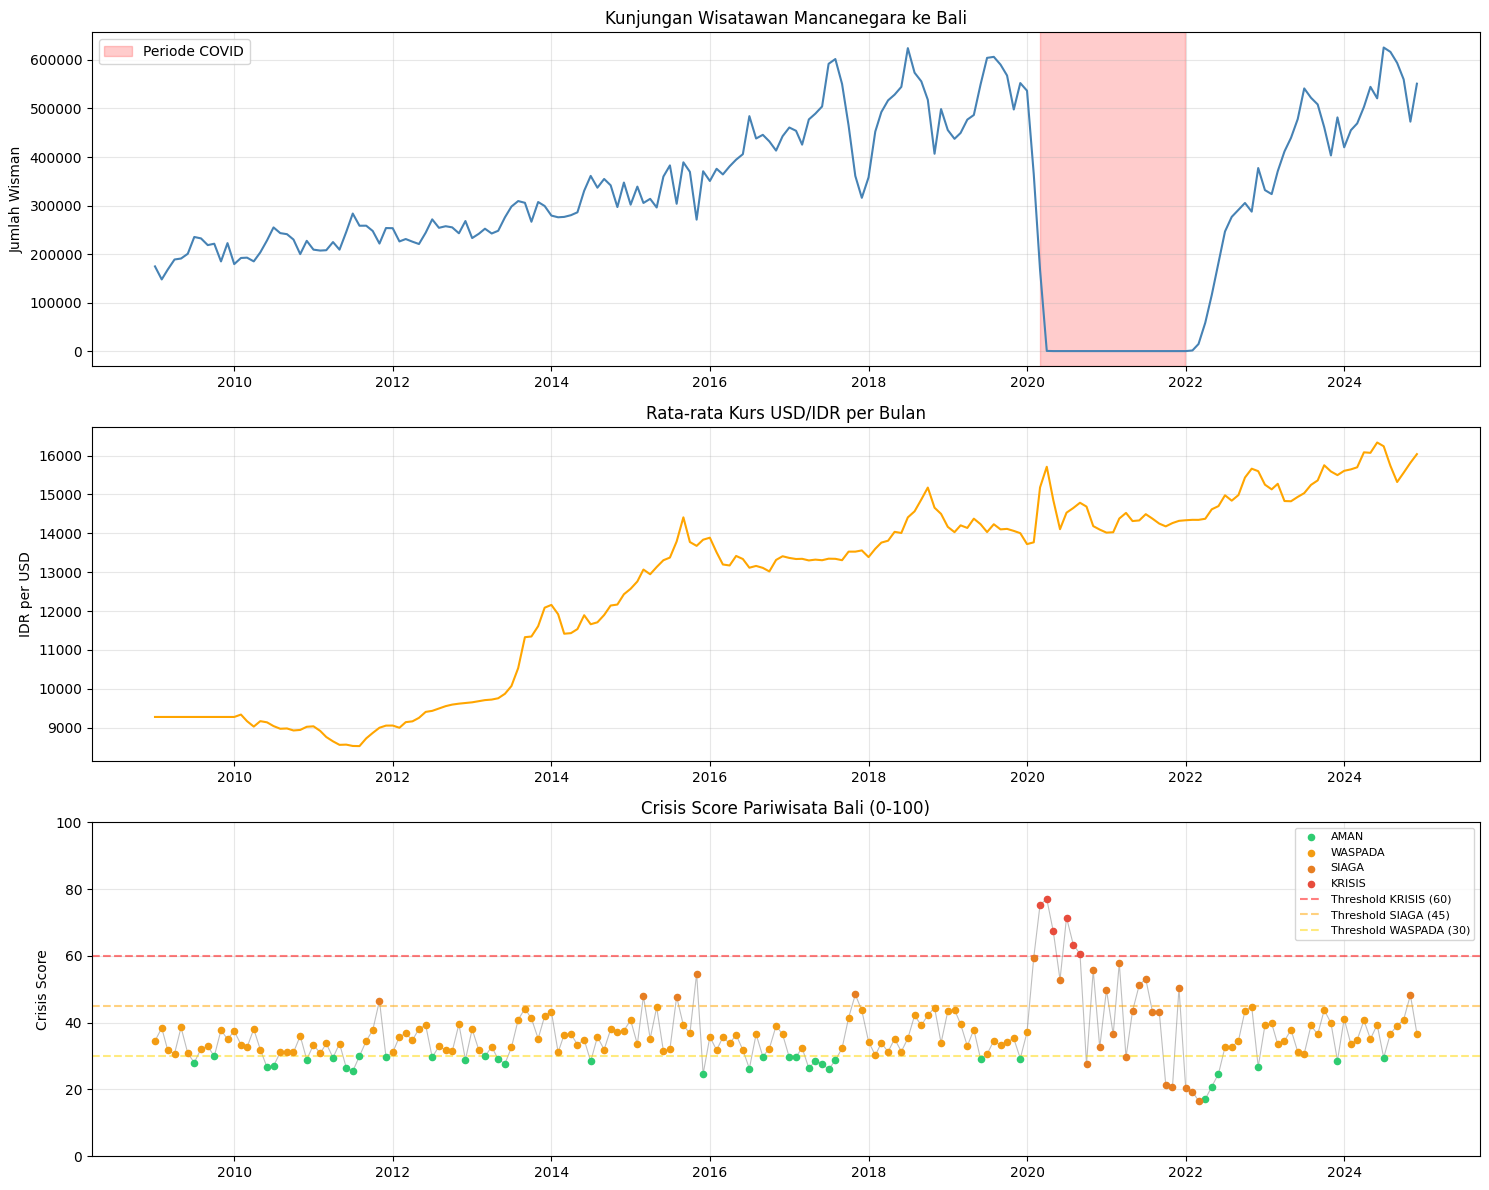

✓ Plot disimpan ke ../data/processed/crisis_score_timeline.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Convert month ke datetime untuk plotting
plot_df = final_df.dropna(subset=['crisis_score_100']).copy()
plot_df['date'] = plot_df['month'].dt.to_timestamp()

# Jumlah Wisman
axes[0].plot(plot_df['date'], plot_df['wisman'], color='steelblue', linewidth=1.5)
axes[0].axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'),
                alpha=0.2, color='red', label='Periode COVID')
axes[0].set_title('Kunjungan Wisatawan Mancanegara ke Bali', fontsize=12)
axes[0].set_ylabel('Jumlah Wisman')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Kurs USD/IDR (jika tersedia)
if 'usd_idr_avg' in plot_df.columns:
    usd_data = plot_df.dropna(subset=['usd_idr_avg'])
    axes[1].plot(usd_data['date'], usd_data['usd_idr_avg'], color='orange', linewidth=1.5)
    axes[1].set_title('Rata-rata Kurs USD/IDR per Bulan', fontsize=12)
    axes[1].set_ylabel('IDR per USD')
    axes[1].grid(alpha=0.3)

# Crisis Score (warna berdasarkan level)
level_colors = {'AMAN': '#2ecc71', 'WASPADA': '#f39c12', 'SIAGA': '#e67e22', 'KRISIS': '#e74c3c'}
for level, color in level_colors.items():
    mask = plot_df['crisis_level'] == level
    axes[2].scatter(plot_df.loc[mask, 'date'], plot_df.loc[mask, 'crisis_score_100'],
                    c=color, label=level, s=20, zorder=3)

axes[2].plot(plot_df['date'], plot_df['crisis_score_100'], color='gray', linewidth=0.8, alpha=0.5)
axes[2].axhline(THRESHOLD_KRISIS,  color='red',    linestyle='--', alpha=0.5, label=f'Threshold KRISIS ({THRESHOLD_KRISIS})')
axes[2].axhline(THRESHOLD_SIAGA,   color='orange', linestyle='--', alpha=0.5, label=f'Threshold SIAGA ({THRESHOLD_SIAGA})')
axes[2].axhline(THRESHOLD_WASPADA, color='gold',   linestyle='--', alpha=0.5, label=f'Threshold WASPADA ({THRESHOLD_WASPADA})')
axes[2].set_title('Crisis Score Pariwisata Bali (0-100)', fontsize=12)
axes[2].set_ylabel('Crisis Score')
axes[2].set_ylim(0, 100)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/crisis_score_timeline.png', dpi=150)
plt.show()
print('✓ Plot disimpan ke ../data/processed/crisis_score_timeline.png')

## 7. Simpan Dataset Final

In [13]:
os.makedirs('../data/final', exist_ok=True)

output_cols = [
    'month',
    # Data mentah
    'wisman', 'wisnus',
    'usd_idr_avg',
    'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed',
    'indonesia_total', 'bali_share_pct',
    'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly', 
    # Features
    'wisman_growth_mom', 'wisman_growth_yoy',
    'wisman_ma3', 'wisman_ma6',
    'wisman_zscore', 'is_anomaly',
    'usd_volatility_3m', 'usd_change_mom',
    'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change',
    # Crisis components
    'crisis_component_tourism',
    'crisis_component_economy',
    'crisis_component_sentiment',
    'external_risk_avg', 'external_risk_max', 'external_risk_range', 'external_risk_score',
    # Crisis score final
    'crisis_score', 'crisis_score_100', 'crisis_level',
    # Lag & trend features
    'wisman_lag_1', 'wisman_lag_3',
    'tpk_lag_1', 'sentiment_lag_1',
    'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m',
    'is_postcovid', 'wisman_recovery_pct',
]

output_cols = [c for c in output_cols if c in final_df.columns]
final_output = final_df[output_cols].copy()

# ── Ganti nilai inf menjadi NaN kemudian ganti menjadi median ────────────────────────────────────────
# Kondisi khusus untuk perhitungan growth dan recovery saat wisman bernilai 0
import numpy as np
_num_cols = final_output.select_dtypes(include=[np.number]).columns
_inf_count = np.isinf(final_output[_num_cols].values).sum()
if _inf_count > 0:
    print(f'⚠  {_inf_count} nilai inf ditemukan -> diganti dengan median kolom')
    for _col in _num_cols:
        if np.isinf(final_output[_col]).any():
            _n = np.isinf(final_output[_col]).sum()
            final_output[_col] = final_output[_col].replace([np.inf, -np.inf], np.nan)
            final_output[_col] = final_output[_col].fillna(final_output[_col].median())
            print(f'   {_col}: {_n} inf -> diisi median')
else:
    print('✓ Tidak ada nilai inf di dataset')
# ─────────────────────────────────────────────────────────────────────────

# Simpan sebagai CSV (backup) DAN Parquet (untuk dashboard)
final_output.to_csv('../data/final/crisis_dataset_final.csv', index=False)

# Konversi month ke string dulu karena Parquet tidak support PeriodIndex
final_parquet = final_output.copy()
final_parquet['month'] = final_parquet['month'].astype(str)
final_parquet.to_parquet('../data/final/master_dataset_clean.parquet', index=False)

print(f'✓ CSV disimpan   : ../data/final/crisis_dataset_final.csv')
print(f'✓ Parquet disimpan: ../data/final/master_dataset_clean.parquet')
print(f'   Shape: {final_output.shape}')
print(f'   Kolom: {output_cols}')
print()
print('✓ Dataset FROZEN — siap untuk modeling (NB05) dan dashboard!')

⚠  6 nilai inf ditemukan -> diganti dengan median kolom
   wisman_growth_mom: 2 inf -> diisi median
   wisman_growth_yoy: 4 inf -> diisi median
✓ CSV disimpan   : ../data/final/crisis_dataset_final.csv
✓ Parquet disimpan: ../data/final/master_dataset_clean.parquet
   Shape: (192, 46)
   Kolom: ['month', 'wisman', 'wisnus', 'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed', 'indonesia_total', 'bali_share_pct', 'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_ma3', 'wisman_ma6', 'wisman_zscore', 'is_anomaly', 'usd_volatility_3m', 'usd_change_mom', 'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change', 'crisis_component_tourism', 'crisis_component_economy', 'crisis_component_sentiment', 'external_risk_avg', 'external_risk_max', 'external_risk_range', 'external_risk_score', 'crisis_score', 'crisis_score_100', 'crisis_level', 'wisma

## 8. Summary & Statistik Akhir

In [14]:
print('=' * 60)
print('RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI')
print('=' * 60)
print(f'Total periode data  : {len(final_output)} bulan')
print(f'Rentang waktu       : {final_output["month"].min()} hingga {final_output["month"].max()}')
print(f'Total fitur         : {len(output_cols) - 2} fitur (+ month dan crisis_level)')
print()
print('Distribusi Level Krisis:')
crisis_dist = final_output['crisis_level'].value_counts()
for level, count in crisis_dist.items():
    emoji = {'AMAN': '🟢', 'WASPADA': '🟡', 'SIAGA': '🟠', 'KRISIS': '🔴'}.get(level, '⚪')
    pct = count / len(final_output) * 100
    print(f'  {emoji} {level}: {count} bulan ({pct:.1f}%)')

print()
print('Statistik Crisis Score:')
cs_stats = final_output['crisis_score_100'].describe()
print(f'  Min   : {cs_stats["min"]:.1f}')
print(f'  Max   : {cs_stats["max"]:.1f}')
print(f'  Mean  : {cs_stats["mean"]:.1f}')
print(f'  Std   : {cs_stats["std"]:.1f}')
print()
print('Langkah selanjutnya:')
print('  -> Buka file crisis_dataset_final.csv untuk analisis lanjutan')
print('  -> Bangun dashboard Streamlit menggunakan data ini')
print('  -> Integrasikan LLM Narrative Engine ke dalam pipeline')

RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI
Total periode data  : 192 bulan
Rentang waktu       : 2009-01 hingga 2024-12
Total fitur         : 44 fitur (+ month dan crisis_level)

Distribusi Level Krisis:
  🟡 WASPADA: 126 bulan (65.6%)
  🟢 AMAN: 34 bulan (17.7%)
  🟠 SIAGA: 26 bulan (13.5%)
  🔴 KRISIS: 6 bulan (3.1%)

Statistik Crisis Score:
  Min   : 16.6
  Max   : 77.0
  Mean  : 36.3
  Std   : 9.3

Langkah selanjutnya:
  -> Buka file crisis_dataset_final.csv untuk analisis lanjutan
  -> Bangun dashboard Streamlit menggunakan data ini
  -> Integrasikan LLM Narrative Engine ke dalam pipeline


---
## 9. Heatmap Korelasi Antar Fitur

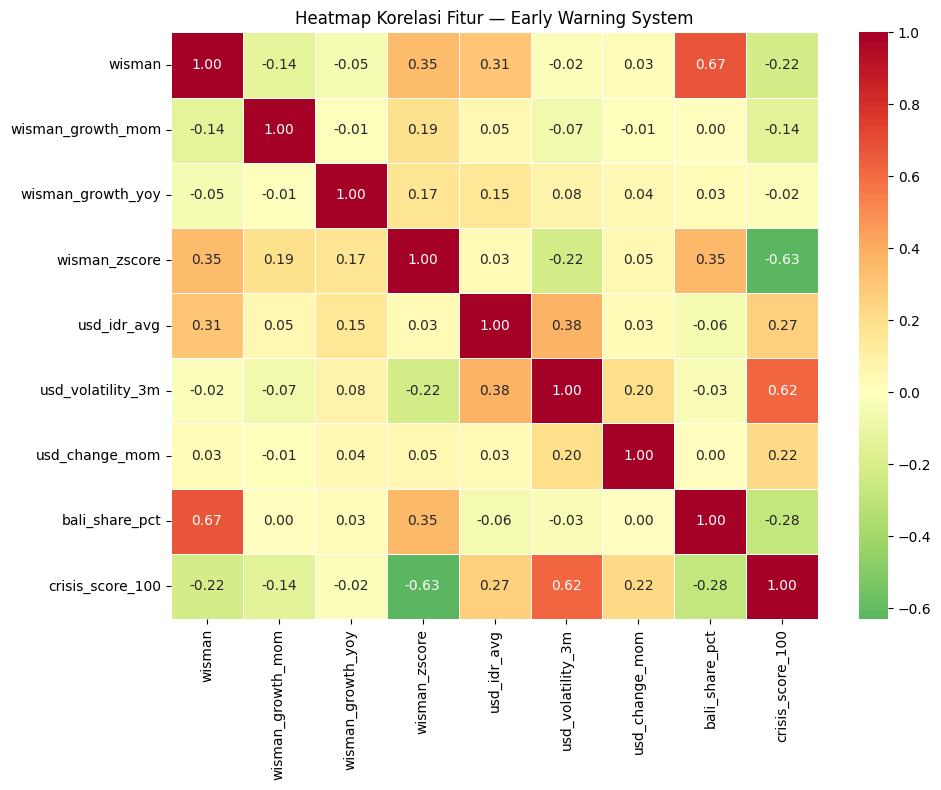

✓ Heatmap disimpan ke ../data/processed/feature_correlation_heatmap.png


In [15]:
# Heatmap korelasi fitur numerik
numeric_cols = [
    'wisman', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_zscore',
    'usd_idr_avg', 'usd_volatility_3m', 'usd_change_mom',
    'bali_share_pct',
    'crisis_score_100'
]
numeric_cols = [c for c in numeric_cols if c in final_output.columns]

corr_matrix = final_output[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur — Early Warning System', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation_heatmap.png', dpi=150)
plt.show()
print('✓ Heatmap disimpan ke ../data/processed/feature_correlation_heatmap.png')

In [16]:
print(final_df['crisis_score_100'].describe())
# Bandingkan dengan nilai lama: min 7.2, max 83.7, mean 40.5

count    192.000000
mean      36.318095
std        9.330780
min       16.625114
25%       31.100403
50%       34.583304
75%       39.295334
max       77.013790
Name: crisis_score_100, dtype: float64


In [17]:
covid = final_df[final_df['month'].dt.year.between(2020, 2021)]
print(covid[['month','crisis_score_100','crisis_level']])
# Kalau ada yang masih AMAN → threshold perlu diturunkan

       month  crisis_score_100 crisis_level
132  2020-01         37.142083      WASPADA
133  2020-02         59.513970        SIAGA
134  2020-03         75.327390       KRISIS
135  2020-04         77.013790       KRISIS
136  2020-05         67.336559       KRISIS
137  2020-06         52.871249        SIAGA
138  2020-07         71.491934       KRISIS
139  2020-08         63.400143       KRISIS
140  2020-09         60.600880       KRISIS
141  2020-10         27.601691        SIAGA
142  2020-11         55.675399        SIAGA
143  2020-12         32.576855        SIAGA
144  2021-01         49.850974        SIAGA
145  2021-02         36.501901        SIAGA
146  2021-03         57.831982        SIAGA
147  2021-04         29.671059        SIAGA
148  2021-05         43.480224        SIAGA
149  2021-06         51.309497        SIAGA
150  2021-07         53.107444        SIAGA
151  2021-08         43.230356        SIAGA
152  2021-09         43.292934        SIAGA
153  2021-10         21.478725  

In [18]:
print(final_df.tail(12)[['month','external_risk_avg','external_risk_score','crisis_score_100']])
# Nilai external_risk harus sama semua (nilai Jan 2024 dibawa maju)

       month  external_risk_avg  external_risk_score  crisis_score_100
180  2024-01           0.411734             0.411734         41.183694
181  2024-02           0.372837             0.372837         33.520337
182  2024-03           0.412344             0.412344         34.906274
183  2024-04           0.391693             0.391693         40.681546
184  2024-05           0.346700             0.346700         35.107060
185  2024-06           0.391392             0.391392         39.408931
186  2024-07           0.355784             0.355784         29.516164
187  2024-08           0.350793             0.350793         36.722917
188  2024-09           0.370901             0.370901         39.082863
189  2024-10           0.381726             0.381726         40.924160
190  2024-11           0.400937             0.400937         48.310736
191  2024-12           0.397827             0.397827         36.744321


In [19]:
import shutil
shutil.copy('../data/final/crisis_dataset_final.csv', 
            '../data/final/crisis_dataset_final_BACKUP.csv')
print('Backup selesai')

Backup selesai


In [21]:
import pandas as pd

df = pd.read_csv('../data/final/crisis_dataset_final.csv')

print(df.shape)
print(df.columns.tolist())

(192, 49)
['month', 'wisman', 'wisnus', 'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed', 'indonesia_total', 'bali_share_pct', 'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_ma3', 'wisman_ma6', 'wisman_zscore', 'is_anomaly', 'usd_volatility_3m', 'usd_change_mom', 'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change', 'crisis_component_tourism', 'crisis_component_economy', 'crisis_component_sentiment', 'external_risk_avg', 'external_risk_max', 'external_risk_range', 'crisis_score', 'crisis_score_100', 'crisis_level', 'wisman_lag_1', 'wisman_lag_3', 'tpk_lag_1', 'sentiment_lag_1', 'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m', 'is_postcovid', 'wisman_recovery_pct', 'physical_risk_score', 'media_risk_score', 'tourist_perception_score', 'external_risk_score']


In [22]:
df2 = df.copy()

df2['crisis_without_external'] = (
    0.45 * df2['crisis_component_tourism']
    + 0.25 * df2['crisis_component_economy']
    + 0.10 * df2['crisis_component_sentiment']
)

impact = (
    df['crisis_score']
    - df2['crisis_without_external']
)

print(impact.describe())

count    192.000000
mean       0.059397
std        0.021621
min        0.031383
25%        0.043767
50%        0.055012
75%        0.069537
max        0.134841
dtype: float64


In [23]:
print(df[
    [
        'crisis_component_tourism',
        'crisis_component_economy',
        'crisis_component_sentiment',
        'external_risk_score'
    ]
].describe())

       crisis_component_tourism  crisis_component_economy  \
count                192.000000                192.000000   
mean                   0.432763                  0.348340   
std                    0.144378                  0.171847   
min                    0.000000                  0.133765   
25%                    0.372194                  0.203118   
50%                    0.435790                  0.317439   
75%                    0.486573                  0.441056   
max                    0.866682                  0.984758   

       crisis_component_sentiment  external_risk_score  
count                  192.000000           192.000000  
mean                     0.219555             0.296990  
std                      0.139223             0.107886  
min                      0.018641             0.165924  
25%                      0.153728             0.218834  
50%                      0.189019             0.275062  
75%                      0.288527             0.347